In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data into a DataFrame
df = pd.read_csv("Working_chr8.txt", sep="\t")

# Display the first few rows of the DataFrame


print(df.columns.tolist())

# Remove the "Unnamed: 36" column
df.drop(columns=['Unnamed: 36'], inplace=True)
df.drop_duplicates(inplace=True)


df.head()
#df.tail()

['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'AC', 'AN', 'AF', 'AC_AFR', 'AF_AFR', 'AN_AFR', 'AC_AMR', 'AF_AMR', 'AN_AMR', 'AC_ASJ', 'AF_ASJ', 'AN_ASJ', 'AC_EAS', 'AF_EAS', 'AN_EAS', 'AC_FIN', 'AF_FIN', 'AN_FIN', 'AC_MID', 'AF_MID', 'AN_MID', 'AC_NFE', 'AF_NFE', 'AN_NFE', 'AC_SAS', 'AF_SAS', 'AN_SAS', 'PREDICTION', 'GENE', 'Unnamed: 36']


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,AC,AN,AF,...,AF_MID,AN_MID,AC_NFE,AF_NFE,AN_NFE,AC_SAS,AF_SAS,AN_SAS,PREDICTION,GENE
0,8,8891127,rs571544041,T,G,.,PASS,11,1461542,7.53E-06,...,0,5768,1,8.99E-07,1112004,3,3.48E-05,86258,Likely_benign,MFHAS1
1,8,8892426,rs374574651,C,T,.,PASS,363,1460486,0.000248547,...,0.00017337,5768,13,1.17E-05,1111588,35,0.00040624,86156,Benign,MFHAS1
2,8,8892708,rs770759826,G,A,.,PASS,4,1428034,2.80E-06,...,0,5348,0,0,1095600,0,0,81934,Likely_benign,MFHAS1
3,8,8892735,rs141278509,C,T,.,PASS,11608,1420864,0.00816968,...,0.00892179,5268,10216,0.00934092,1093682,288,0.00355222,81076,Benign,MFHAS1
4,8,8892823,rs115597655,G,C,.,PASS,1510,1440882,0.00104797,...,0.000350877,5700,65,5.90E-05,1102370,7,8.39E-05,83424,Benign,MFHAS1


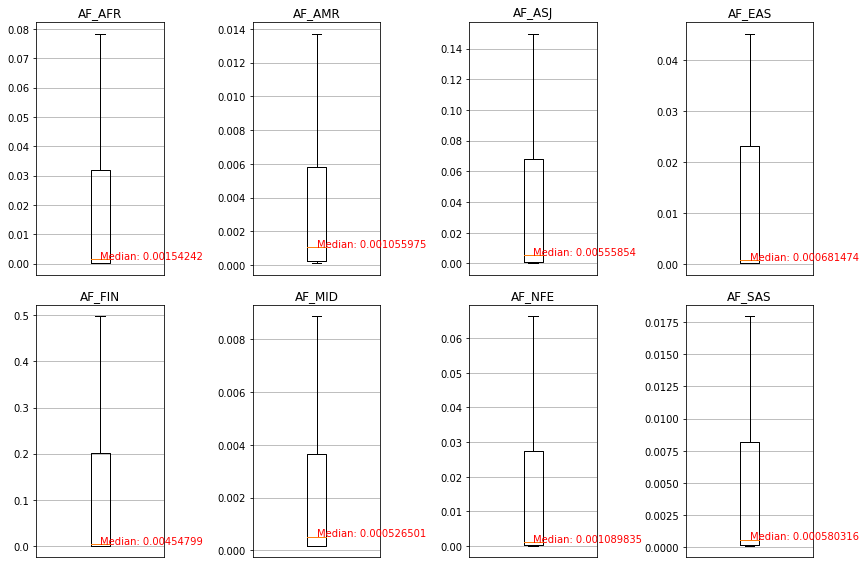

In [2]:
# # Calculate summary statistics for AF of cancer genes for each population
# populations = ['AF_AFR', 'AF_AMR', 'AF_ASJ', 'AF_EAS', 'AF_FIN', 'AF_MID', 'AF_NFE', 'AF_SAS']
# population_stats = df[populations].describe()

# for column in populations:
#     # Convert non-numeric entries to NaN
#     df[column] = pd.to_numeric(df[column], errors='coerce')

# # Filter out data less than 10^-4
# filtered_df = df.copy()
# for population in populations:
#     filtered_df[population] = df[population][df[population] >= 1e-4]

# # Create box plots for each population
# plt.figure(figsize=(12, 8))
# for i, population in enumerate(populations):
#     plt.subplot(2, 4, i+1)
#     plt.boxplot(filtered_df[population].dropna(), showfliers=False)

#     # Calculate mean AF
#     mean_value = np.mean(df[population].dropna())
    
#     # Round the mean AF to precision of 10^-9
#     mean_value_rounded = round(mean_value, 9)
    
#     # Calculate median AF
#     median_value = np.median(filtered_df[population].dropna())
    
#     # Round the median AF to the same precision as the mean
#     median_value_rounded = round(median_value, 9)
    
#     # Annotate the plot with the mean and median AF
#     plt.text(1, mean_value, f"Mean: {mean_value_rounded}\nMedian: {median_value_rounded}", fontsize=10, color='red')
    
#     plt.title(population)
#     plt.xticks([])
#     plt.grid(True)  # Add grid lines for better visualization

# plt.tight_layout()
# plt.show()



# Calculate summary statistics for AF of cancer genes for each population
populations = ['AF_AFR', 'AF_AMR', 'AF_ASJ', 'AF_EAS', 'AF_FIN', 'AF_MID', 'AF_NFE', 'AF_SAS']
population_stats = df[populations].describe()

for column in populations:
    # Convert non-numeric entries to NaN
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Filter out data less than 10^-4
filtered_df = df.copy()
for population in populations:
    filtered_df[population] = df[population][df[population] >= 1e-4]

# Create box plots for each population
plt.figure(figsize=(12, 8))
for i, population in enumerate(populations):
    plt.subplot(2, 4, i+1)
    plt.boxplot(filtered_df[population].dropna(), showfliers=False)

    # Calculate median AF
    median_value = np.median(filtered_df[population].dropna())
    
    # Round the median AF to the same precision as the mean
    median_value_rounded = round(median_value, 9)
    
    # Annotate the plot with the median AF only
    plt.text(1, median_value, f"Median: {median_value_rounded}", fontsize=10, color='red')
    
    plt.title(population)
    plt.xticks([])
    plt.grid(True)  # Add grid lines for better visualization

plt.tight_layout()
plt.show()


Differences in Cancer Gene Frequency: The box plots reveal variations in allele frequency (AF) distributions among different populations. African and American populations tend to have higher median AF values compared to Middle Eastern and South Asian populations. This suggests that certain cancer genes may be more prevalent or have higher frequencies in African and American populations.

Identification of Potentially Pathogenic Cancer Genes: Populations with higher median AF values may indicate the presence of cancer genes that are more pathogenic or associated with a higher risk of cancer development. Therefore, African and American populations may harbor cancer genes with greater pathogenic potential compared to Middle Eastern and South Asian populations.

Population-Specific Sensitivity to Cancer Genes: The observed differences in AF distributions suggest that certain populations may exhibit increased sensitivity or susceptibility to specific cancer genes. For example, if a particular gene associated with prostate cancer shows higher AF in African populations compared to other populations, it suggests that African individuals may have a higher risk of developing prostate cancer due to genetic factors.

In [3]:
'''
Identify Genes with Consistently Higher Allele Frequency (AF) Across Populations:
Iterate through each cancer gene and calculate its median AF across all populations.
Keep track of the top 5 genes with the highest median AF values.

These genes are universally responsible for higher AFs which are potentially dangerous and could lead to cancer 
'''
# Define populations
populations = ['AF_AFR', 'AF_AMR', 'AF_ASJ', 'AF_EAS', 'AF_FIN', 'AF_MID', 'AF_NFE', 'AF_SAS']

# Convert non-numeric entries to NaN and then to numeric type for each population column
for population in populations:
    df[population] = pd.to_numeric(df[population], errors='coerce')

# Group the DataFrame by gene and calculate the mean AF across all populations for each gene
gene_af_means = df.groupby('GENE')[populations].mean()

# Find the top 5 genes with the highest mean AF across all populations
top_genes = gene_af_means.mean(axis=1).nlargest(5)
print(top_genes)

GENE
ADGRB1    0.058435
CDH17     0.054702
ZFHX4     0.021049
EXT1      0.010378
RNF170    0.009778
dtype: float64


In [4]:
'''
You can find the top 5 genes with the highest allele frequency (AF) 
for each population by sorting the AF values within each population column. Here's how you can modify the code to achieve that:
'''

# Define populations
populations = ['AF_AFR', 'AF_AMR', 'AF_ASJ', 'AF_EAS', 'AF_FIN', 'AF_MID', 'AF_NFE', 'AF_SAS']

# Convert non-numeric entries to NaN and then to numeric type for each population column
for population in populations:
    df[population] = pd.to_numeric(df[population], errors='coerce')

# Find the top 5 genes with the highest AF for each population
top_genes_per_population = {}
for population in populations:
    top_genes_per_population[population] = df.nlargest(5, population)[['GENE', population]]

# Print the top genes with the highest AF for each population
for population, top_genes_df in top_genes_per_population.items():
    print(f"Top 5 genes with highest AF in {population}:")
    print(top_genes_df)
    print()

Top 5 genes with highest AF in AF_AFR:
        GENE    AF_AFR
5898  RECQL4  0.998201
6107  RECQL4  0.998148
3776  RECQL4  0.995997
5849  RECQL4  0.984466
739      WRN  0.935997

Top 5 genes with highest AF in AF_AMR:
        GENE    AF_AMR
739      WRN  0.997316
1359     WRN  0.996442
47       WRN  0.991010
142      WRN  0.988426
5898  RECQL4  0.912987

Top 5 genes with highest AF in AF_ASJ:
        GENE    AF_ASJ
739      WRN  1.000000
3776  RECQL4  0.999962
5849  RECQL4  0.999962
6107  RECQL4  0.999962
5898  RECQL4  0.999956

Top 5 genes with highest AF in AF_EAS:
     GENE    AF_EAS
142   WRN  1.000000
739   WRN  1.000000
1359  WRN  1.000000
47    WRN  0.999949
200   WRN  0.875151

Top 5 genes with highest AF in AF_FIN:
        GENE    AF_FIN
1359     WRN  1.000000
739      WRN  0.999981
142      WRN  0.999884
47       WRN  0.999098
3776  RECQL4  0.996367

Top 5 genes with highest AF in AF_MID:
        GENE    AF_MID
6107  RECQL4  0.998613
5898  RECQL4  0.998449
739      WRN  0.9980

In [5]:
'''
CREATE GENE INFO CSV FOR STACKED BAR CHARTS
'''
import pandas as pd
import numpy as np
import csv
from collections import defaultdict

everything = list()
all_gene_types = list()
all_predictions = list()
with open('Working_chr8.txt', 'r') as file:
    reader = csv.reader(file, delimiter='\t')
    for row in reader:
        # Remove empty strings
        row = list(filter(None, row))
        everything.append(row)
        if row[-1] != 'GENE' and 'GENEINFO=' not in row[-1]:
            all_gene_types.append(row[-1])
        if row[-2] != 'PREDICTION':
            if 'CLNSIG=' in row[-2]:
                 all_predictions.append(row[-2][len('CLNSIG='):])
            else:
                all_predictions.append(row[-2])

gene_names = np.unique(all_gene_types)
predictions = np.unique(all_predictions)

# Define the severity levels for each category
severity_levels = {
    'Benign': 0,
    'Benign/Likely_benign': 1,
    'Likely_benign': 2,
    'Uncertain_significance': 3,
    'Conflicting_interpretations_of_pathogenicity': 4,
    'Conflicting_interpretations_of_pathogenicity|risk_factor': 5,
    'Likely_pathogenic': 6,
    'Pathogenic/Likely_pathogenic': 7,
    'Pathogenic': 8,
    'not_provided': 9
}


# Sort the list based on severity levels
predictions = sorted(predictions, key=lambda x: severity_levels[x])

# Count how many times the gene shows up
ult = {gene: [0] * (len(predictions) + 1) for gene in gene_names}

for gene in gene_names:
    for row in everything:
        if gene in row[-1]:
            ult[gene][0] += 1
            for i in range(len(predictions)):
                if predictions[i] in row[-2]:
                    ult[gene][i + 1] += 1

# Define the column names for the CSV file
columns = ['Gene', 'Frequency'] + list(severity_levels.keys())

# Create a DataFrame from the ult dictionary
df = pd.DataFrame(ult).T.reset_index()
print(columns)
print(df)

# Set column names
df.columns = columns

# Export DataFrame to CSV
df.to_csv('gene_info.csv', index=False)

['Gene', 'Frequency', 'Benign', 'Benign/Likely_benign', 'Likely_benign', 'Uncertain_significance', 'Conflicting_interpretations_of_pathogenicity', 'Conflicting_interpretations_of_pathogenicity|risk_factor', 'Likely_pathogenic', 'Pathogenic/Likely_pathogenic', 'Pathogenic', 'not_provided']
      index     0   1   2    3     4    5  6   7   8    9  10
0    ADGRB1    10   7   0    2     0    0  0   0   0    0   1
1     CDH17     9   6   0    2     1    0  0   0   0    0   0
2      EXT1   244  37   5   77   102    9  0   3   3   22   2
3    MFHAS1     5   3   0    2     0    0  0   0   0    0   0
4       NBN  1417  95  41  416   664  163  1  79  40   76   5
5    RB1CC1    19  12   0    6     0    0  0   1   0    0   0
6    RECQL4  2720  95  43  936  1536   56  0  42  15  109   4
7    RNF139     1   0   0    0     1    0  0   0   0    0   0
8    RNF170    14   5   1    2     3    3  0   1   0    1   0
9    RNF19A     1   1   0    0     0    0  0   0   0    0   0
10  RUNX1T1     7   6   0   

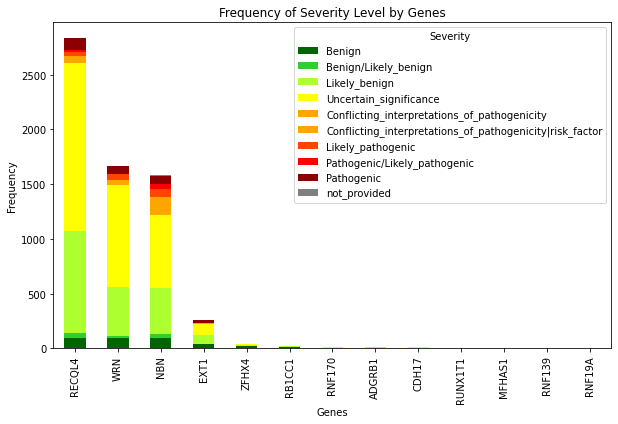

In [6]:
''' 
CODE TO CREATE STACKED BAR CHARTS
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
df = pd.read_csv('gene_info.csv')

# Set the Gene column as the index
df.set_index('Gene', inplace=True)

# Get the severity levels
severity_levels = df.columns[1:]

# Define colors for each severity level
colors = {
    'Benign': 'darkgreen',
    'Benign/Likely_benign': 'limegreen',
    'Likely_benign': 'greenyellow',
    'Uncertain_significance': 'yellow',
    'Conflicting_interpretations_of_pathogenicity': 'orange',
    'Conflicting_interpretations_of_pathogenicity|risk_factor': 'orange',
    'Likely_pathogenic': 'orangered',
    'Pathogenic/Likely_pathogenic': 'red',
    'Pathogenic': 'darkred',
    'not_provided': 'grey'
}

# Sort the DataFrame by the sum of frequencies
df_sorted = df.loc[df.iloc[:, 1:].sum(axis=1).sort_values(ascending=False).index]

# Plot the stacked bar chart without the 'Frequency' column
ax = df_sorted.iloc[:, 1:].plot(kind='bar', stacked=True, figsize=(10, 6), color=[colors[level] for level in severity_levels])

# Set the title and labels
ax.set_title('Frequency of Severity Level by Genes')
ax.set_xlabel('Genes')
ax.set_ylabel('Frequency')

# Set the legend inside the plot area
ax.legend(title='Severity')

# Show the plot
plt.show()


RECQL4, WRN, NBN, EXT1, ZFHX4: These genes have the highest frequencies across severity levels, indicating that they are associated with a wide range of severity levels of genetic variants. The presence of more pathogenic and likely pathogenic genes among these indicates a potential association with various diseases, including cancer.

To determine the types of cancer associated with these genes, further analysis would involve consulting databases or literature on genetics and cancer research. RECQL4, WRN, NBN, EXT1, and ZFHX4 have been linked to various types of cancer:

RECQL4: Associated with Rothmund-Thomson syndrome, which increases the risk of developing osteosarcoma and skin cancer.
WRN: Mutations in this gene are associated with Werner syndrome, which predisposes individuals to various cancers, including soft tissue sarcomas, osteosarcomas, and thyroid cancer.
NBN: Mutations in this gene increase the risk of breast cancer, particularly in individuals of Ashkenazi Jewish descent, as well as other cancers such as prostate and colorectal cancer.
EXT1: Mutations in this gene cause hereditary multiple exostoses, a condition characterized by the development of benign bone tumors known as osteochondromas, which may lead to the development of osteosarcoma.
ZFHX4: Associated with susceptibility to colorectal cancer and other gastrointestinal cancers.
These are just a few examples, and further research would be needed to fully understand the relationship between these genes and cancer types.

In [13]:
import pandas as pd
import numpy as np

# Read the Working_chr8.txt file into a DataFrame
df = pd.read_csv("Working_chr8.txt", sep="\t")

# Define the populations
populations = ['AF_AFR', 'AF_AMR', 'AF_ASJ', 'AF_EAS', 'AF_FIN', 'AF_MID', 'AF_NFE', 'AF_SAS']

# Extract data for the specific genes: RECQL4, WRN, NBN, EXT1, ZFHX4
specific_genes = ['RECQL4', 'WRN', 'NBN', 'EXT1', 'ZFHX4']

# Define severity levels
severity_levels = {
    'Benign': 0,
    'Likely_benign': 1,
    'Benign/Likely_benign': 2,
    'Uncertain_significance': 3,
    'Conflicting_interpretations_of_pathogenicity': 4,
    'Conflicting_interpretations_of_pathogenicity|risk_factor': 5,
    'Likely_pathogenic': 6,
    'Pathogenic/Likely_pathogenic': 7,
    'Pathogenic': 8,
    'not_provided': 9
}

# Initialize a dictionary to store frequencies for each gene, population, and severity level
gene_population_severity_freq = {(gene, population): {level: 0 for level in severity_levels} for gene in specific_genes for population in populations}

# Calculate frequencies
for gene in specific_genes:
    for population in populations:
        gene_data = df[df['GENE'] == gene]
        for level, freq in gene_data['PREDICTION'].value_counts().items():
            gene_population_severity_freq[(gene, population)][level] = freq

# Convert the dictionary to a DataFrame
df_gene_population_severity_freq = pd.DataFrame(gene_population_severity_freq).T

# Export DataFrame to CSV
df_gene_population_severity_freq.to_csv('gene_population_severity_frequency.csv')

C:\Users\harol\AppData\Local\Temp/ipykernel_30360/2373134455.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Severity_Score'] = df_filtered['PREDICTION'].map(severity_levels)
C:\Users\harol\AppData\Local\Temp/ipykernel_30360/2373134455.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[population] = pd.to_numeric(df_filtered[population], errors='coerce').fillna(0)
C:\Users\harol\AppData\Local\Temp/ipykernel_30360/2373134455.py:62: SettingWithCopyWarning: 
A value is trying to

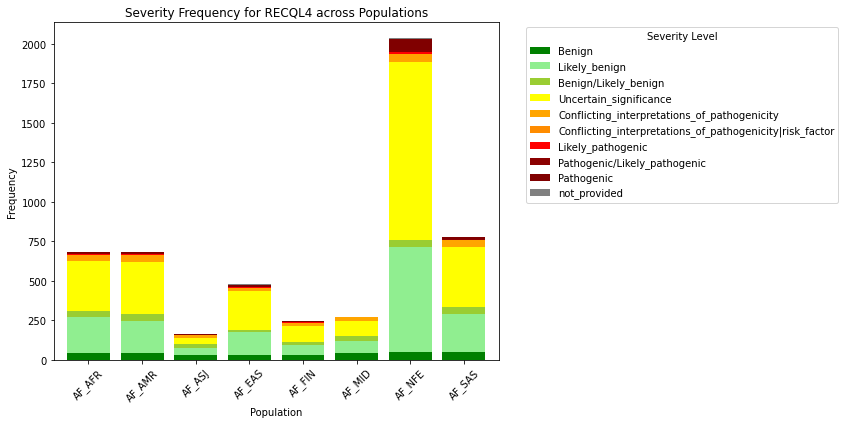

C:\Users\harol\AppData\Local\Temp/ipykernel_30360/2373134455.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_data.drop(columns=['Gene'], inplace=True)


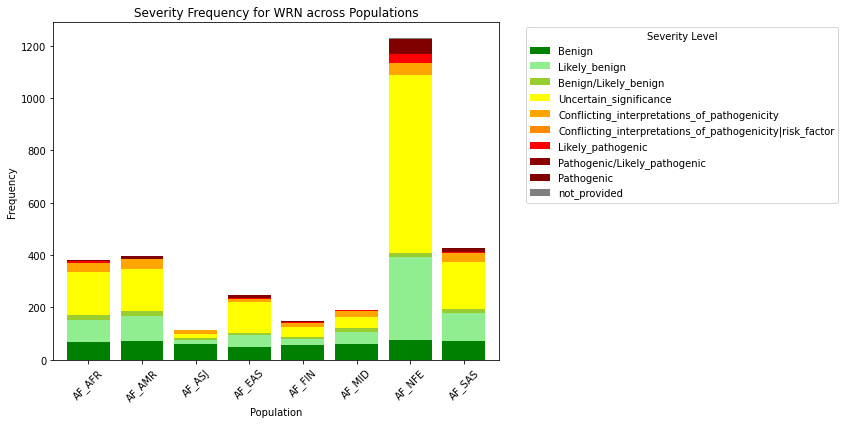

C:\Users\harol\AppData\Local\Temp/ipykernel_30360/2373134455.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_data.drop(columns=['Gene'], inplace=True)


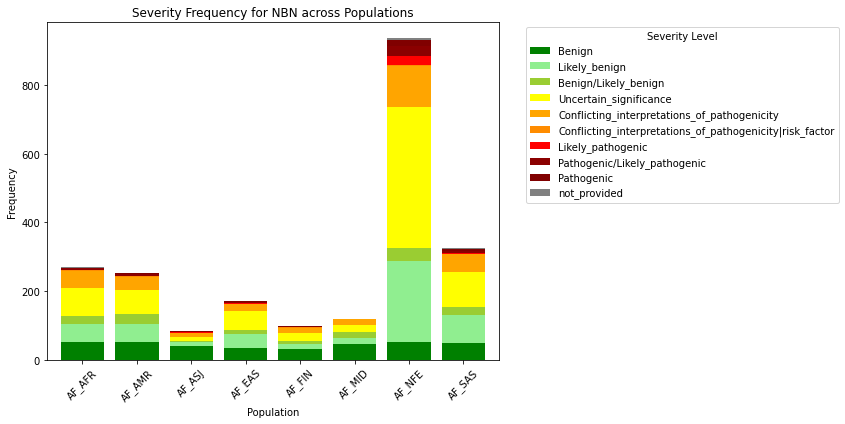

C:\Users\harol\AppData\Local\Temp/ipykernel_30360/2373134455.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_data.drop(columns=['Gene'], inplace=True)


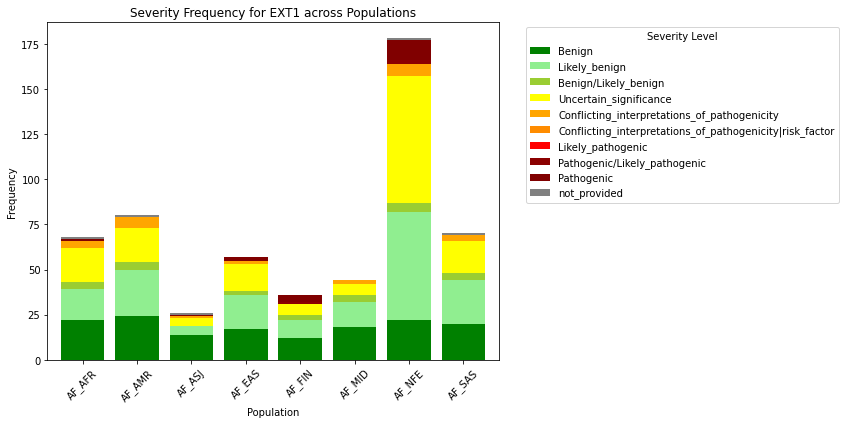

C:\Users\harol\AppData\Local\Temp/ipykernel_30360/2373134455.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_data.drop(columns=['Gene'], inplace=True)


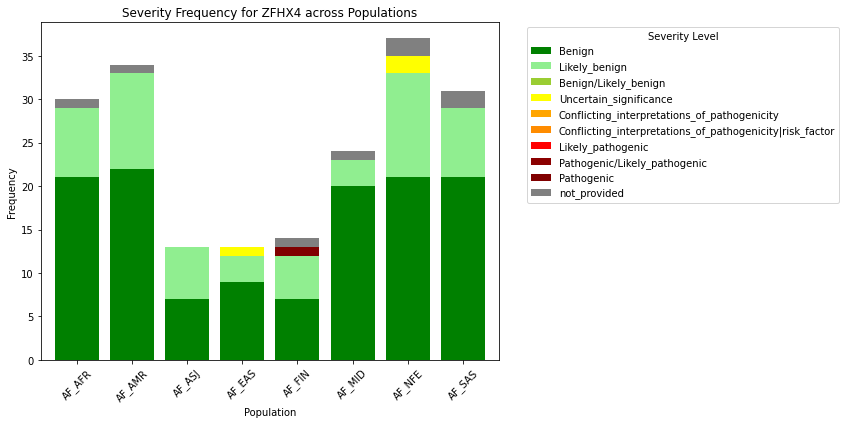

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data into a DataFrame
df = pd.read_csv("Working_chr8.txt", sep="\t")

# Remove the "Unnamed: 36" column and duplicates
df.drop(columns=['Unnamed: 36'], inplace=True)
df.drop_duplicates(inplace=True)

# Specify genes of interest
genes_of_interest = ['RECQL4', 'WRN', 'NBN', 'EXT1', 'ZFHX4']

# Define the severity levels and corresponding numeric values
severity_levels = {
    'Benign': 0,
    'Likely_benign': 1,
    'Benign/Likely_benign': 2,
    'Uncertain_significance': 3,
    'Conflicting_interpretations_of_pathogenicity': 4,
    'Conflicting_interpretations_of_pathogenicity|risk_factor': 5,
    'Likely_pathogenic': 6,
    'Pathogenic/Likely_pathogenic': 7,
    'Pathogenic': 8,
    'not_provided': 9
}

# Filter data for the genes of interest and map predictions to severity scores
df_filtered = df[df['GENE'].isin(genes_of_interest)]
df_filtered['Severity_Score'] = df_filtered['PREDICTION'].map(severity_levels)

# Convert population frequency columns to numeric values
populations = ['AF_AFR', 'AF_AMR', 'AF_ASJ', 'AF_EAS', 'AF_FIN', 'AF_MID', 'AF_NFE', 'AF_SAS']
for population in populations:
    df_filtered[population] = pd.to_numeric(df_filtered[population], errors='coerce').fillna(0)

# Initialize data structure for plotting
plot_data = {gene: {pop: [0] * len(severity_levels) for pop in populations} for gene in genes_of_interest}

# Populate plot_data with counts
for index, row in df_filtered.iterrows():
    gene = row['GENE']
    severity_score = row['Severity_Score']
    for population in populations:
        if row[population] > 0:
            plot_data[gene][population][severity_score] += 1

# Convert plot_data to DataFrame format
plot_df_list = []
for gene, pop_data in plot_data.items():
    for pop, counts in pop_data.items():
        plot_df_list.append([gene, pop] + counts)
plot_df = pd.DataFrame(plot_df_list, columns=['Gene', 'Population'] + list(severity_levels.keys()))

# Define colors for severity levels
colors = ['green', 'lightgreen', 'yellowgreen', 'yellow', 'orange', 'darkorange', 'red', 'darkred', 'maroon', 'grey']

# Plotting
for gene in genes_of_interest:
    gene_data = plot_df[plot_df['Gene'] == gene]
    gene_data.set_index('Population', inplace=True)
    gene_data.drop(columns=['Gene'], inplace=True)

    ax = gene_data.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors, width=0.8)
    ax.set_title(f'Severity Frequency for {gene} across Populations')
    ax.set_ylabel('Frequency')
    ax.set_xlabel('Population')
    plt.xticks(rotation=45)
    plt.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [9]:
import pandas as pd
import numpy as np

# Read the Working_chr8.txt file into a DataFrame
df = pd.read_csv("Working_chr8.txt", sep="\t")

# Define the populations
populations = ['AF_AFR', 'AF_AMR', 'AF_ASJ', 'AF_EAS', 'AF_FIN', 'AF_MID', 'AF_NFE', 'AF_SAS']

# Extract data for the specific genes: RECQL4, WRN, NBN, EXT1, ZFHX4
specific_genes = ['RECQL4', 'WRN', 'NBN', 'EXT1', 'ZFHX4']

# Define severity levels
severity_levels = {
    'Benign': 0,
    'Likely_benign': 1,
    'Benign/Likely_benign': 2,
    'Uncertain_significance': 3,
    'Conflicting_interpretations_of_pathogenicity': 4,
    'Conflicting_interpretations_of_pathogenicity|risk_factor': 5,
    'Likely_pathogenic': 6,
    'Pathogenic/Likely_pathogenic': 7,
    'Pathogenic': 8,
    'not_provided': 9
}

# Initialize a dictionary to store frequencies for each gene, population, and severity level
gene_population_severity_freq = {(gene, population): {level: 0 for level in severity_levels} for gene in specific_genes for population in populations}

# Calculate frequencies
for gene in specific_genes:
    for population in populations:
        gene_data = df[df['GENE'] == gene]
        for level, freq in gene_data['PREDICTION'].value_counts().items():
            gene_population_severity_freq[(gene, population)][level] = freq

# Convert the dictionary to a DataFrame
df_gene_population_severity_freq = pd.DataFrame(gene_population_severity_freq).T

# Export DataFrame to CSV
df_gene_population_severity_freq.to_csv('gene_population_severity_frequency.csv')


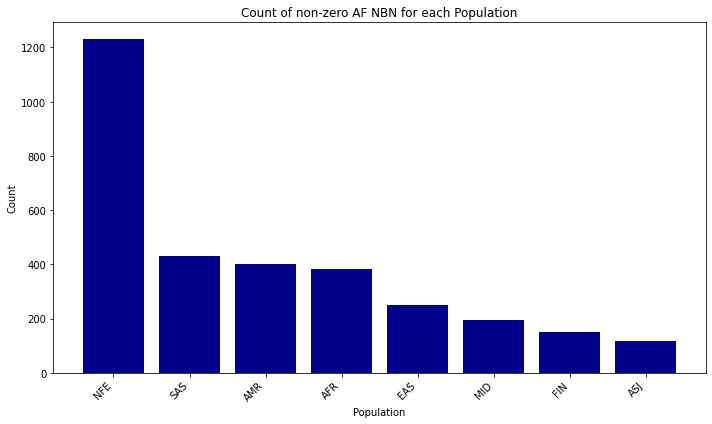

In [10]:
import matplotlib.pyplot as plt

with open('Working_chr8.txt', 'r') as file:
    first_line = file.readline().strip()
    elements = first_line.split('\t')
    pop = [element.replace('AF_', '') for element in elements if element.startswith('AF_')]
    count = [0 for _ in pop]
    af_indices = [index for index, element in enumerate(elements) if element.startswith('AF_')]
    for line in file:
        row = line.strip().split('\t')
        if 'WRN' in row[-1]:
            for index in af_indices:
                if row[index] != '0':
                    count[af_indices.index(index)] += 1
    
    sorted_data = sorted(zip(pop, count), key=lambda x: x[1], reverse=True)
    pop_sorted, count_sorted = zip(*sorted_data)

    plt.figure(figsize=(10, 6))
    plt.bar(pop_sorted, count_sorted, color='darkblue')

    plt.xlabel('Population')
    plt.ylabel('Count')
    plt.title('Count of non-zero AF NBN for each Population')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

['8', '8891127', 'rs571544041', 'T', 'G', '.', 'PASS', '11', '1461542', '7.53E-06', '0', '0', '33480', '0', '0', '44722', '0', '0', '26136', '1', '2.52E-05', '39700', '0', '0', '53082', '0', '0', '5768', '1', '8.99E-07', '1112004', '3', '3.48E-05', '86258', 'Likely_benign', 'MFHAS1']
['8', '8892426', 'rs374574651', 'C', 'T', '.', 'PASS', '363', '1460486', '0.000248547', '3', '8.97E-05', '33462', '4', '8.96E-05', '44648', '0', '0', '26096', '192', '0.00484042', '39666', '0', '0', '52794', '1', '0.00017337', '5768', '13', '1.17E-05', '1111588', '35', '0.00040624', '86156', 'Benign', 'MFHAS1']
['8', '8892708', 'rs770759826', 'G', 'A', '.', 'PASS', '4', '1428034', '2.80E-06', '4', '0.000121588', '32898', '0', '0', '40448', '0', '0', '24924', '0', '0', '38460', '0', '0', '49572', '0', '0', '5348', '0', '0', '1095600', '0', '0', '81934', 'Likely_benign', 'MFHAS1']
['8', '8892735', 'rs141278509', 'C', 'T', '.', 'PASS', '11608', '1420864', '0.00816968', '43', '0.00132675', '32410', '145', '0.0

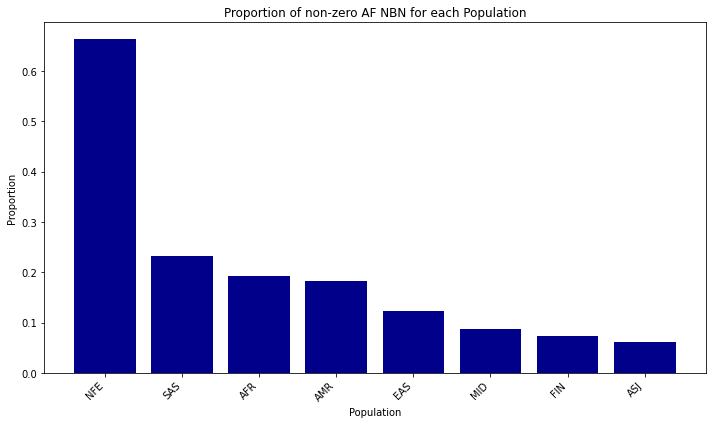

In [11]:
import matplotlib.pyplot as plt

with open('Working_chr8.txt', 'r') as file:
    # RECQL4, WRN, NBN, EXT1, ZFHX4: 
    first_line = file.readline().strip()
    elements = first_line.split('\t')
    pop = [element.replace('AF_', '') for element in elements if element.startswith('AF_')]
    count = [0 for _ in pop]
    total_counts = [0 for _ in pop]  # To store total counts for each population
    af_indices = [index for index, element in enumerate(elements) if element.startswith('AF_')]
    for line in file:
        row = line.strip().split('\t')
        print(row)
        if 'NBN' in row[-1]:
            for index in af_indices:
                total_counts[af_indices.index(index)] += 1  # Increment total count
                if row[index] != '0':
                    count[af_indices.index(index)] += 1
    
    # Calculate proportions
    proportions = [c / total if total != 0 else 0 for c, total in zip(count, total_counts)]

    sorted_data = sorted(zip(pop, proportions), key=lambda x: x[1], reverse=True)
    pop_sorted, proportions_sorted = zip(*sorted_data)

    plt.figure(figsize=(10, 6))
    plt.bar(pop_sorted, proportions_sorted, color='darkblue')

    plt.xlabel('Population')
    plt.ylabel('Proportion')
    plt.title('Proportion of non-zero AF NBN for each Population')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('Working_chr8.txt', delimiter='\t')

# Specify the genes of interest
genes_of_interest = ['RECQL4', 'WRN', 'NBN', 'EXT1', 'ZFHX4']

# Specify the populations
populations = ['AF_AFR', 'AF_AMR', 'AF_ASJ', 'AF_EAS', 'AF_FIN', 'AF_MID', 'AF_NFE', 'AF_SAS']

# Define severity levels
severity_levels = ['Benign', 'Likely_benign', 'Benign/Likely_benign', 'Uncertain_significance',
                   'Conflicting_interpretations_of_pathogenicity', 'Conflicting_interpretations_of_pathogenicity|risk_factor',
                   'Likely_pathogenic', 'Pathogenic/Likely_pathogenic', 'Pathogenic', 'not_provided']

# Specify the severity levels of interest
severity_levels_of_interest = ['Likely_pathogenic', 'Pathogenic/Likely_pathogenic', 'Pathogenic', 'not_provided']

# Create pie charts for each population and gene
for population in populations:
    for gene in genes_of_interest:
        # Filter data for the current population and gene
        filtered_data = df[(df['GENE'] == gene) & (df['Population'] == population)]

        # Initialize a dictionary to store severity counts
        severity_counts = {severity: 0 for severity in severity_levels_of_interest}

        # Count the frequency of severity levels
        for severity in severity_levels_of_interest:
            if severity in filtered_data['Severity'].values:
                severity_counts[severity] = filtered_data['Severity'].value_counts()[severity]

        # Create a pie chart if there are severity counts
        if any(severity_counts.values()):
            plt.figure(figsize=(8, 6))
            plt.pie(severity_counts.values(), labels=severity_counts.keys(), autopct='%1.1f%%', startangle=140)
            plt.title(f'Distribution of Specific Severity Levels for {gene} in Population {population}')
            plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
            plt.show()


KeyError: 'Population'